<a href="https://colab.research.google.com/github/opdrin09/Arquivos_colab/blob/main/Trabalho_3_Portico_FEM_231012639.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Trabalho 3 — Elementos Finitos para Vibração
## Desafio 3: pórtico industrial com viga treliçada e cabo estabilizador

Pofessora: Marcela R. Machado

Aluno: Pedro Henrique da Silva Costa | Matrícula: 231012639

Link do colab: https://colab.research.google.com/drive/1qI79T8FqNSJ-jXL3yxMiYn3bZI2U-Wcx?usp=sharing

Este notebook monta dois modelos dinâmicos de elementos finitos para o pórtico do enunciado:

1. **Modelo completo**, com colunas, banzos, montantes, diagonais e cabo discretizados individualmente.
2. **Modelo equivalente**, em que a treliça é substituída por uma viga equivalente para comparação dos modos globais.

A malha é gerada com **Gmsh**, pois o objetivo não é apenas escrever as matrizes, mas também deixar claro como a geometria foi discretizada e como cada família de elementos foi separada por grupo físico.


## Leitura física do problema

O pórtico reúne componentes com comportamentos estruturais diferentes. Por isso, a modelagem foi separada por tipo de elemento:

- as **colunas W** foram tratadas como elementos de pórtico plano, pois trabalham com esforço axial, esforço cortante, flexão e rotação nodal;
- a **treliça principal** foi modelada barra a barra, considerando banzos, montantes e diagonais como elementos axiais articulados;
- o **cabo estabilizador** foi tratado como elemento de cabo pré-tracionado, articulado nas extremidades, sem transmissão de momento;
- o **motor desbalanceado** foi representado por uma força harmônica de frequência igual a 600 rpm, ou seja, 10 Hz.

A análise compara três situações: sem cabo, cabo sem pré-tração e cabo com pré-tração de 80 kN. Essa comparação é importante porque um cabo sem tração inicial não tem o mesmo efeito dinâmico de um cabo efetivamente estabilizador.


## Respostas diretas ao enunciado

**1. Elementos para as colunas.**  
As colunas foram modeladas com elementos de **pórtico plano/viga de Timoshenko**, com graus de liberdade horizontais, verticais e rotacionais. Essa escolha é foi selecionada porque as colunas recebem esforço axial, cortante e momento fletor. Usar barra simples seria inadequado, pois uma barra de treliça não transmite momento e subestimaria a rigidez lateral do pórtico.

**2. Elementos para a treliça.**  
No modelo completo, cada barra da treliça foi representada como elemento axial articulado. Essa escolha preserva a função estrutural de banzos, montantes e diagonais. Também foi criado um modelo de **viga equivalente**, usado apenas como comparação global. A viga equivalente aproxima alguns modos globais de flexão, mas não representa modos locais das barras, deformações relativas entre painéis nem a redistribuição real dos esforços na treliça.

**3. Elemento para o cabo.**  
O cabo foi modelado como **elemento de cabo pré-tracionado**, articulado nas extremidades, sem rigidez de flexão e sem transmissão de momento. A matriz do elemento considera a soma da rigidez axial material com a rigidez geométrica associada à tração inicial:

$$
\mathbf{K}_{cabo} = \mathbf{K}_{axial} + \mathbf{K}_{geom}
$$

com:

$$
\mathbf{K}_{axial} \propto \frac{EA}{L}
\qquad\text{e}\qquad
\mathbf{K}_{geom} \propto \frac{T_0}{L}
$$

O cabo estabilizador depende da tração inicial para contribuir de forma transversal. Quando se retira a pré-tração, aparecem modos quase nulos associados ao cabo, o que indica que ele não está atuando como estabilizador.

**4. Força do motor.**  
A força desbalanceada foi modelada como força harmônica rotativa:

$$
F_0 = m e \omega^2
$$

com:

$$
m = 120\,\text{kg},\quad
e = 0{,}05\,\text{m},\quad
f = 10\,\text{Hz},\quad
\omega = 2\pi f
$$

Com esses valores, a amplitude da força desbalanceada é de aproximadamente:

$$
F_0 \approx 23{,}7\,\text{kN}
$$

Essa força foi aplicada no nó central da treliça, correspondente à posição do motor.

**5. Treliça completa versus viga contínua.**  
A viga equivalente permite uma estimativa simplificada de alguns modos globais. Porém, ela elimina a cinemática interna da treliça e não representa diretamente a participação de diagonais, montantes e modos locais. Por esse motivo, o modelo completo barra a barra é mais foi selecionado para responder ao desafio proposto.



## 1. Importações e configuração

Nesta etapa são carregadas as bibliotecas numéricas e o **Gmsh**. O `gmsh` é requisito do trabalho, então o notebook para com uma mensagem explícita caso ele não esteja instalado.


In [ ]:
# === 1. IMPORTAÇÕES E CONFIGURAÇÕES ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from collections import Counter

try:
    import gmsh
except Exception as exc:
    !apt-get install -y gmsh
    !pip install --upgrade gmsh

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linestyle"] = ":"
plt.rcParams["grid.alpha"] = 0.35


## 2. Parâmetros físicos e carregamento do motor

Os valores abaixo vêm do enunciado: colunas W200×46, barras tubulares 50×50×3 mm, cabo de 200 mm², pré-tração de 80 kN e motor de 120 kg a 600 rpm.

A rotação de 600 rpm corresponde a uma frequência de excitação de:

$$
f = 10\,\text{Hz}
$$

Assim, a interpretação dos resultados deve verificar se há frequências naturais próximas dessa faixa e, principalmente, se essas frequências aparecem como modos globais da estrutura ou apenas como modos locais do cabo.


In [ ]:
# === 2. PROPRIEDADES FÍSICAS E CONTEXTO ===
E_steel = 200e9      # Pa (Módulo de Young do aço)
rho_steel = 7850.0   # kg/m3 (Massa específica do aço)
nu_steel = 0.3       # Coeficiente de Poisson do aço
G_steel = E_steel / (2.0 * (1.0 + nu_steel)) # Módulo de cisalhamento do aço

# Colunas (Perfil W200x46)
A_col = 5880e-6      # m2 (Área de seção transversal)
I_col = 45.6e-6      # m4 (Momento de inércia)
As_col = 1.4616e-3   # m2 (Área de cisalhamento: d * t_w = 203 * 7.2 mm2)

# Treliça (Tubo 50x50x3)
A_bar = 564e-6     # m2 (Área de seção de cada barra)
I_bar = 2.085e-7     # m4 (Momento de inércia de cada barra)
As_bar = A_bar / 1.2 # Área de cisalhamento retangular aproximada

# Cabo Estabilizador
A_cab = 200e-6       # m2 (Área de seção transversal)
T_cab = 80000.0      # N (Tensão nominal inicial)

# Motor Rotativo
m_motor = 120.0     # kg (Massa do motor)
e_motor = 0.05       # m (Excentricidade do rotor)
rpm_motor = 600.0    # RPM
freq_motor = rpm_motor / 60.0  # 10 Hz
omega_motor = 2.0 * np.pi * freq_motor  # 62.83 rad/s
F0_motor = m_motor * e_motor * omega_motor**2  # Amplitude da força centrífuga

# Amortecimento histerético adotado nas respostas forçadas/FRF
eta = 0.02

print(f"Frequência do motor: {freq_motor:.2f} Hz")
print(f"Amplitude da força desbalanceada F0 = {F0_motor/1000:.2f} kN")
print(f"Amortecimento histerético adotado na resposta forçada: eta = {eta:.3f}")


Frequência do motor: 10.00 Hz
Amplitude da força desbalanceada F0 = 23.69 kN
Amortecimento histerético adotado na resposta forçada: eta = 0.020


### Discussão da excitação

A força calculada para o motor desbalanceado foi de aproximadamente **23,7 kN**. Portanto, a excitação não é desprezível em comparação com a escala da estrutura analisada.

Foi adotado amortecimento histerético de **2%** na análise de resposta forçada. Essa hipótese evita uma resposta não física de amplitude ilimitada exatamente nas frequências naturais e permite comparar os casos de forma mais estável. Ainda assim, o valor de amortecimento é uma hipótese simplificada; portanto, as amplitudes devem ser interpretadas como estimativas numéricas do modelo.


## 3. Matrizes locais dos elementos

Foram usados três tipos de elemento:

- **viga/pórtico de Timoshenko**, para as colunas e para a viga equivalente;
- **barra axial de treliça**, para banzos, montantes e diagonais;
- **elemento de cabo pré-tracionado**, para o cabo estabilizador.

O cabo não foi tratado como pórtico, pois não transmite momento fletor nas extremidades. Também não foi tratado como barra axial comum sem pré-tração, pois sua contribuição transversal depende da rigidez geométrica criada pela tração inicial.

No sistema local do cabo, considerando os graus de liberdade translacionais:

$$
\{u_1, v_1, u_2, v_2\}
$$

a matriz tangente é escrita como soma de uma parte axial material e uma parte geométrica:

$$
\mathbf{k}_{cabo}^{local}
=
\frac{EA}{L}
\begin{bmatrix}
1 & 0 & -1 & 0\\
0 & 0 & 0 & 0\\
-1 & 0 & 1 & 0\\
0 & 0 & 0 & 0
\end{bmatrix}
+
\frac{T_0}{L}
\begin{bmatrix}
0 & 0 & 0 & 0\\
0 & 1 & 0 & -1\\
0 & 0 & 0 & 0\\
0 & -1 & 0 & 1
\end{bmatrix}
$$

A primeira parcela representa o alongamento axial. A segunda representa a rigidez geométrica transversal causada pela pré-tração. Quando se adota $$T_0 = 0$$, essa segunda contribuição desaparece.


In [ ]:
# === 3. MATRIZES LOCAIS DE ELEMENTOS FINITOS ===
def get_timoshenko_beam_matrices(E, A, I, As, rho, nu, p1, p2):
    L = np.linalg.norm(p2 - p1)
    c = (p2[0] - p1[0]) / L
    s = (p2[1] - p1[1]) / L
    G = E / (2.0 * (1.0 + nu))

    # Parametro de cisalhamento
    Phi = (12.0 * E * I) / (G * As * L**2)

    # Matriz de rotação
    T = np.array([
        [ c,  s, 0,  0,  0, 0],
        [-s,  c, 0,  0,  0, 0],
        [ 0,  0, 1,  0,  0, 0],
        [ 0,  0, 0,  c,  s, 0],
        [ 0,  0, 0, -s,  c, 0],
        [ 0,  0, 0,  0,  0, 1]
    ])

    # Matriz de rigidez local de Timoshenko
    k_loc = np.zeros((6, 6))
    k_loc[0, 0] = E * A / L
    k_loc[0, 3] = -E * A / L
    k_loc[3, 0] = -E * A / L
    k_loc[3, 3] = E * A / L

    factor = E * I / (L**3 * (1.0 + Phi))
    k_loc[1, 1] = 12.0 * factor
    k_loc[1, 2] = 6.0 * L * factor
    k_loc[1, 4] = -12.0 * factor
    k_loc[1, 5] = 6.0 * L * factor

    k_loc[2, 1] = 6.0 * L * factor
    k_loc[2, 2] = (4.0 + Phi) * L**2 * factor
    k_loc[2, 4] = -6.0 * L * factor
    k_loc[2, 5] = (2.0 - Phi) * L**2 * factor

    k_loc[4, 1] = -12.0 * factor
    k_loc[4, 2] = -6.0 * L * factor
    k_loc[4, 4] = 12.0 * factor
    k_loc[4, 5] = -6.0 * L * factor

    k_loc[5, 1] = 6.0 * L * factor
    k_loc[5, 2] = (2.0 - Phi) * L**2 * factor
    k_loc[5, 4] = -6.0 * L * factor
    k_loc[5, 5] = (4.0 + Phi) * L**2 * factor

    # Matriz de massa consistente de Timoshenko (Archer/Przemieniecki)
    m_trans = np.zeros((6, 6))
    m_trans[0, 0] = rho * A * L / 3.0
    m_trans[0, 3] = rho * A * L / 6.0
    m_trans[3, 0] = rho * A * L / 6.0
    m_trans[3, 3] = rho * A * L / 3.0

    m_bend_coef = rho * A * L / (420.0 * (1.0 + Phi)**2)
    m_trans[1, 1] = m_bend_coef * (156.0 + 294.0 * Phi + 140.0 * Phi**2)
    m_trans[1, 2] = m_bend_coef * (22.0 + 38.5 * Phi + 17.5 * Phi**2) * L
    m_trans[1, 4] = m_bend_coef * (54.0 + 126.0 * Phi + 70.0 * Phi**2)
    m_trans[1, 5] = m_bend_coef * -(13.0 + 31.5 * Phi + 17.5 * Phi**2) * L

    m_trans[2, 1] = m_trans[1, 2]
    m_trans[2, 2] = m_bend_coef * (4.0 + 7.0 * Phi + 3.5 * Phi**2) * L**2
    m_trans[2, 4] = m_bend_coef * (13.0 + 31.5 * Phi + 17.5 * Phi**2) * L
    m_trans[2, 5] = m_bend_coef * -(3.0 + 7.0 * Phi + 3.5 * Phi**2) * L**2

    m_trans[4, 1] = m_trans[1, 4]
    m_trans[4, 2] = m_trans[2, 4]
    m_trans[4, 4] = m_bend_coef * (156.0 + 294.0 * Phi + 140.0 * Phi**2)
    m_trans[4, 5] = m_bend_coef * -(22.0 + 38.5 * Phi + 17.5 * Phi**2) * L

    m_trans[5, 1] = m_trans[1, 5]
    m_trans[5, 2] = m_trans[2, 5]
    m_trans[5, 4] = m_trans[4, 5]
    m_trans[5, 5] = m_bend_coef * (4.0 + 7.0 * Phi + 3.5 * Phi**2) * L**2

    # Inercia rotatoria (M_rot)
    m_rot = np.zeros((6, 6))
    m_rot_coef = rho * I / (30.0 * L * (1.0 + Phi)**2)
    m_rot[1, 1] = m_rot_coef * 36.0
    m_rot[1, 2] = m_rot_coef * (3.0 - 15.0 * Phi) * L
    m_rot[1, 4] = m_rot_coef * -36.0
    m_rot[1, 5] = m_rot_coef * (3.0 - 15.0 * Phi) * L

    m_rot[2, 1] = m_rot[1, 2]
    m_rot[2, 2] = m_rot_coef * (4.0 + 5.0 * Phi + 10.0 * Phi**2) * L**2
    m_rot[2, 4] = m_rot_coef * -(3.0 - 15.0 * Phi) * L
    m_rot[2, 5] = m_rot_coef * -(1.0 - 5.0 * Phi - 5.0 * Phi**2) * L**2

    m_rot[4, 1] = m_rot[1, 4]
    m_rot[4, 2] = m_rot[2, 4]
    m_rot[4, 4] = m_rot_coef * 36.0
    m_rot[4, 5] = m_rot_coef * -(3.0 - 15.0 * Phi) * L

    m_rot[5, 1] = m_rot[1, 5]
    m_rot[5, 2] = m_rot[2, 5]
    m_rot[5, 4] = m_rot[4, 5]
    m_rot[5, 5] = m_rot_coef * (4.0 + 5.0 * Phi + 10.0 * Phi**2) * L**2

    m_loc = m_trans + m_rot
    return T.T @ k_loc @ T, T.T @ m_loc @ T

def get_truss_element_matrices(E, A, rho, p1, p2):
    L = np.linalg.norm(p2 - p1)
    c = (p2[0] - p1[0]) / L
    s = (p2[1] - p1[1]) / L
    T = np.array([
        [ c,  s, 0,  0,  0, 0],
        [-s,  c, 0,  0,  0, 0],
        [ 0,  0, 1,  0,  0, 0],
        [ 0,  0, 0,  c,  s, 0],
        [ 0,  0, 0, -s,  c, 0],
        [ 0,  0, 0,  0,  0, 1]
    ])
    k_loc = np.zeros((6, 6))
    k_loc[0, 0] = E*A/L
    k_loc[0, 3] = -E*A/L
    k_loc[3, 0] = -E*A/L
    k_loc[3, 3] = E*A/L
    m_loc = np.zeros((6, 6))
    m_loc[0, 0] = rho*A*L/3.0
    m_loc[1, 1] = rho*A*L/3.0
    m_loc[0, 3] = rho*A*L/6.0
    m_loc[1, 4] = rho*A*L/6.0
    m_loc[3, 0] = rho*A*L/6.0
    m_loc[4, 1] = rho*A*L/6.0
    m_loc[3, 3] = rho*A*L/3.0
    m_loc[4, 4] = rho*A*L/3.0
    return T.T @ k_loc @ T, T.T @ m_loc @ T

def get_cable_element_matrices(E, A, rho, T0, p1, p2):
    """Elemento de cabo 2D pré-tracionado, articulado nas extremidades.

    Modelo usado:
    - graus de liberdade efetivos: ux_i, uy_i, ux_j, uy_j;
    - sem rigidez rotacional;
    - sem rigidez flexional EI;
    - rigidez material axial EA/L;
    - rigidez geométrica transversal T0/L.

    Isso representa um cabo/tirante linearizado em torno da configuração
    inicialmente tracionada. Para T0 = 0, o cabo praticamente não contribui
    com rigidez transversal inicial.
    """
    L = np.linalg.norm(p2 - p1)
    c = (p2[0] - p1[0]) / L
    s = (p2[1] - p1[1]) / L

    # Transformação dos deslocamentos globais [ux1, uy1, ux2, uy2]
    # para o sistema local do cabo [u1, v1, u2, v2].
    T4 = np.array([
        [ c,  s, 0.0, 0.0],
        [-s,  c, 0.0, 0.0],
        [0.0, 0.0,  c,  s],
        [0.0, 0.0, -s,  c]
    ])

    # Rigidez axial material: o cabo resiste ao alongamento ao longo do seu eixo.
    k_axial_local = (E * A / L) * np.array([
        [ 1.0, 0.0, -1.0, 0.0],
        [ 0.0, 0.0,  0.0, 0.0],
        [-1.0, 0.0,  1.0, 0.0],
        [ 0.0, 0.0,  0.0, 0.0]
    ])

    # Rigidez geométrica: nasce da pré-tração e atua nos deslocamentos transversais.
    k_geom_local = (T0 / L) * np.array([
        [0.0,  0.0, 0.0,  0.0],
        [0.0,  1.0, 0.0, -1.0],
        [0.0,  0.0, 0.0,  0.0],
        [0.0, -1.0, 0.0,  1.0]
    ])

    # Massa consistente translacional do cabo. Não há massa rotacional associada,
    # porque este elemento não possui grau de liberdade físico de rotação.
    m_local = (rho * A * L / 6.0) * np.array([
        [2.0, 0.0, 1.0, 0.0],
        [0.0, 2.0, 0.0, 1.0],
        [1.0, 0.0, 2.0, 0.0],
        [0.0, 1.0, 0.0, 2.0]
    ])

    k_global_4 = T4.T @ (k_axial_local + k_geom_local) @ T4
    m_global_4 = T4.T @ m_local @ T4

    # Embutir em uma matriz 6x6 compatível com o resto do código:
    # [ux1, uy1, theta1, ux2, uy2, theta2].
    k_global = np.zeros((6, 6))
    m_global = np.zeros((6, 6))
    idx = [0, 1, 3, 4]
    for a, ia in enumerate(idx):
        for b, ib in enumerate(idx):
            k_global[ia, ib] = k_global_4[a, b]
            m_global[ia, ib] = m_global_4[a, b]

    return k_global, m_global


### Comentário sobre a escolha dos elementos

A escolha dos elementos é uma parte muito importante da modelagem. Se toda a estrutura fosse modelada como viga, a treliça receberia rigidez flexional artificial em barras que deveriam trabalhar predominantemente à tração ou compressão. Se toda a estrutura fosse modelada como barra, as colunas deixariam de transmitir momento fletor.

Por isso, o modelo completo separa os comportamentos: colunas como pórtico, treliça como barras axiais e cabo como elemento de cabo pré-tracionado. Essa separação reduz o risco de obter frequências naturais numericamente válidas, mas fisicamente associadas a uma idealização incorreta.



## 4. Malha Gmsh do modelo completo

Aqui o Gmsh gera a geometria 1D do pórtico completo. Os grupos físicos separam as famílias de elementos:

- `column`: colunas;
- `chord`: banzos superior e inferior;
- `vertical`: montantes;
- `diagonal`: diagonais;
- `cable`: cabo estabilizador.

Essa separação é importante porque cada grupo recebe uma matriz local diferente na montagem global.


In [ ]:
# === 4. NÓS E CONECTIVIDADE DA TRELIÇA COMPLETA VIA GMSH ===
def generate_full_model_mesh_gmsh(lc_columns=1.0, lc_chords=1.0, lc_cable=1.0):
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("full_model")

    # Pontos do pórtico
    p_left_base = gmsh.model.geo.addPoint(0.0, 0.0, 0.0)
    p_left_mid = gmsh.model.geo.addPoint(0.0, 6.0, 0.0)
    p_left_top = gmsh.model.geo.addPoint(0.0, 8.0, 0.0)
    p_right_base = gmsh.model.geo.addPoint(40.0, 0.0, 0.0)
    p_right_mid = gmsh.model.geo.addPoint(40.0, 6.0, 0.0)
    p_right_top = gmsh.model.geo.addPoint(40.0, 8.0, 0.0)

    # Pontos do banzo superior (espaçamento de 5m)
    p_top_chords = [p_left_top]
    for x in [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0]:
        p_top_chords.append(gmsh.model.geo.addPoint(x, 8.0, 0.0))
    p_top_chords.append(p_right_top)

    # Pontos do banzo inferior (espaçamento de 5m)
    p_bot_chords = [p_left_mid]
    for x in [5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0]:
        p_bot_chords.append(gmsh.model.geo.addPoint(x, 6.0, 0.0))
    p_bot_chords.append(p_right_mid)

    # Linhas de colunas
    l_col_left_1 = gmsh.model.geo.addLine(p_left_base, p_left_mid)
    l_col_left_2 = gmsh.model.geo.addLine(p_left_mid, p_left_top)
    l_col_right_1 = gmsh.model.geo.addLine(p_right_base, p_right_mid)
    l_col_right_2 = gmsh.model.geo.addLine(p_right_mid, p_right_top)

    # Linhas de banzos superior e inferior
    l_top_chords = []
    for i in range(8):
        l_top_chords.append(gmsh.model.geo.addLine(p_top_chords[i], p_top_chords[i+1]))

    l_bot_chords = []
    for i in range(8):
        l_bot_chords.append(gmsh.model.geo.addLine(p_bot_chords[i], p_bot_chords[i+1]))

    # Linhas de montantes verticais
    l_verticals = []
    for i in range(1, 8):
        l_verticals.append(gmsh.model.geo.addLine(p_bot_chords[i], p_top_chords[i]))

    # Linhas de diagonais (Warren)
    l_diagonals = []
    l_diagonals.append(gmsh.model.geo.addLine(p_bot_chords[0], p_top_chords[1]))
    l_diagonals.append(gmsh.model.geo.addLine(p_top_chords[1], p_bot_chords[2]))
    l_diagonals.append(gmsh.model.geo.addLine(p_bot_chords[2], p_top_chords[3]))
    l_diagonals.append(gmsh.model.geo.addLine(p_top_chords[3], p_bot_chords[4]))
    l_diagonals.append(gmsh.model.geo.addLine(p_bot_chords[4], p_top_chords[5]))
    l_diagonals.append(gmsh.model.geo.addLine(p_top_chords[5], p_bot_chords[6]))
    l_diagonals.append(gmsh.model.geo.addLine(p_bot_chords[6], p_top_chords[7]))
    l_diagonals.append(gmsh.model.geo.addLine(p_top_chords[7], p_bot_chords[8]))

    # Linha do cabo estabilizador
    l_cable = gmsh.model.geo.addLine(p_left_top, p_bot_chords[4])

    gmsh.model.geo.synchronize()

    # Discretização com Transfinite Curves
    gmsh.model.mesh.setTransfiniteCurve(l_col_left_1, max(2, int(6.0 / lc_columns) + 1))
    gmsh.model.mesh.setTransfiniteCurve(l_col_left_2, max(2, int(2.0 / lc_columns) + 1))
    gmsh.model.mesh.setTransfiniteCurve(l_col_right_1, max(2, int(6.0 / lc_columns) + 1))
    gmsh.model.mesh.setTransfiniteCurve(l_col_right_2, max(2, int(2.0 / lc_columns) + 1))

    for l in l_top_chords:
        gmsh.model.mesh.setTransfiniteCurve(l, 2)
    for l in l_bot_chords:
        gmsh.model.mesh.setTransfiniteCurve(l, 2)

    for l in l_verticals:
        gmsh.model.mesh.setTransfiniteCurve(l, 2)
    for l in l_diagonals:
        gmsh.model.mesh.setTransfiniteCurve(l, 2)

    gmsh.model.mesh.setTransfiniteCurve(l_cable, max(2, int(20.1 / lc_cable) + 1))

    gmsh.model.addPhysicalGroup(1, [l_col_left_1, l_col_left_2, l_col_right_1, l_col_right_2], tag=1, name="column")
    gmsh.model.addPhysicalGroup(1, l_top_chords + l_bot_chords, tag=2, name="chord")
    gmsh.model.addPhysicalGroup(1, l_verticals, tag=3, name="vertical")
    gmsh.model.addPhysicalGroup(1, l_diagonals, tag=4, name="diagonal")
    gmsh.model.addPhysicalGroup(1, [l_cable], tag=5, name="cable")

    gmsh.model.mesh.generate(1)

    nodeTags, coords, _ = gmsh.model.mesh.getNodes()
    nodes = coords.reshape(-1, 3)[:, :2]
    node_map = {tag: i for i, tag in enumerate(nodeTags)}

    elements_by_group = []
    groups = gmsh.model.getPhysicalGroups(1)
    for g_dim, g_tag in groups:
        g_name = gmsh.model.getPhysicalName(g_dim, g_tag)
        entities = gmsh.model.getEntitiesForPhysicalGroup(g_dim, g_tag)
        for ent in entities:
            elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(g_dim, ent)
            if len(elemTypes) > 0:
                line_idx = np.where(elemTypes == 1)[0][0]
                tags = elemTags[line_idx]
                node_tags = elemNodeTags[line_idx].reshape(-1, 2)
                for t, n_t in zip(tags, node_tags):
                    elements_by_group.append((node_map[n_t[0]], node_map[n_t[1]], g_name))

    gmsh.finalize()
    return nodes, elements_by_group

nodes_full, elements_full = generate_full_model_mesh_gmsh(lc_columns=1.0, lc_chords=1.0, lc_cable=1.0)

print("Malha completa gerada com Gmsh:")
print(f"  nós = {len(nodes_full)}")
print(f"  elementos = {len(elements_full)}")
print(f"  grupos = {dict(Counter([el[2] for el in elements_full]))}")


Malha completa gerada com Gmsh:
  nós = 51
  elementos = 67
  grupos = {'column': 16, 'chord': 16, 'vertical': 7, 'diagonal': 8, 'cable': 20}


## 5. Modelo de viga equivalente

A treliça também foi substituída por uma viga equivalente no eixo médio:

$$
y = 7\,\text{m}
$$

Isso evita comparar a treliça completa com uma viga fictícia colocada no topo ou em uma posição fisicamente diferente.

Este modelo não pretende substituir o completo. Ele existe para responder ao desafio final do enunciado: o que se ganha e o que se perde ao trocar uma treliça por uma viga contínua.


In [20]:
# === 6. PROPRIEDADES DA VIGA EQUIVALENTE E MONTAGEM VIA GMSH ===
from collections import Counter

def generate_beam_model_mesh_gmsh(lc_columns=1.0, lc_beam=1.0, lc_cable=1.0):
    y_eq = 7.0
    gmsh.initialize()
    try:
        gmsh.option.setNumber("General.Terminal", 0); gmsh.model.add("beam_model")

        p_left_base = gmsh.model.geo.addPoint(0, 0, 0); p_left_eq = gmsh.model.geo.addPoint(0, y_eq, 0); p_left_top = gmsh.model.geo.addPoint(0, 8, 0)
        p_right_base = gmsh.model.geo.addPoint(40, 0, 0); p_right_eq = gmsh.model.geo.addPoint(40, y_eq, 0); p_right_top = gmsh.model.geo.addPoint(40, 8, 0)

        p_beam_nodes = [p_left_eq] + [gmsh.model.geo.addPoint(x, y_eq, 0) for x in [5, 10, 15, 20, 25, 30, 35]] + [p_right_eq]

        l_cols = [
            gmsh.model.geo.addLine(p_left_base, p_left_eq), gmsh.model.geo.addLine(p_left_eq, p_left_top),
            gmsh.model.geo.addLine(p_right_base, p_right_eq), gmsh.model.geo.addLine(p_right_eq, p_right_top)
        ]
        l_beams = [gmsh.model.geo.addLine(p_beam_nodes[i], p_beam_nodes[i+1]) for i in range(len(p_beam_nodes)-1)]
        l_cable = gmsh.model.geo.addLine(p_left_top, p_beam_nodes[4])

        gmsh.model.geo.synchronize()

        for l, L, lc in [(l_cols[0], y_eq, lc_columns), (l_cols[1], 8-y_eq, lc_columns), (l_cols[2], y_eq, lc_columns), (l_cols[3], 8-y_eq, lc_columns)]:
            gmsh.model.mesh.setTransfiniteCurve(l, max(2, int(L/lc) + 1))
        for l in l_beams:
            gmsh.model.mesh.setTransfiniteCurve(l, max(2, int(5.0/lc_beam) + 1))
        gmsh.model.mesh.setTransfiniteCurve(l_cable, max(2, int(np.sqrt(20.0**2 + (8.0-y_eq)**2)/lc_cable) + 1))

        gmsh.model.addPhysicalGroup(1, l_cols, tag=1, name="column")
        gmsh.model.addPhysicalGroup(1, l_beams, tag=2, name="truss_beam")
        gmsh.model.addPhysicalGroup(1, [l_cable], tag=3, name="cable")

        gmsh.model.mesh.generate(1)
        nodeTags, coords, _ = gmsh.model.mesh.getNodes()
        nodes = coords.reshape(-1, 3)[:, :2]; node_map = {tag: i for i, tag in enumerate(nodeTags)}

        elements_by_group = []
        for g_dim, g_tag in gmsh.model.getPhysicalGroups(1):
            g_name = gmsh.model.getPhysicalName(g_dim, g_tag)
            for ent in gmsh.model.getEntitiesForPhysicalGroup(g_dim, g_tag):
                elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(g_dim, ent)
                for elem_type, tags, node_tags_raw in zip(elemTypes, elemTags, elemNodeTags):
                    if elem_type != 1: continue
                    for n1, n2 in node_tags_raw.reshape(-1, 2):
                        elements_by_group.append((node_map[n1], node_map[n2], g_name))
    finally:
        gmsh.finalize()

    return nodes, elements_by_group


nodes_beam, elements_beam = generate_beam_model_mesh_gmsh(lc_columns=1.0, lc_beam=1.0, lc_cable=1.0)

print("Malha equivalente gerada com Gmsh:")
print(f"  nós = {len(nodes_beam)}")
print(f"  elementos = {len(elements_beam)}")
print(f"  grupos = {dict(Counter([el[2] for el in elements_beam]))}")


def assemble_beam_model(nodes, elements, cable_tension=None):
    A_eq = 2.0*A_bar; I_eq = 2.0*A_bar*(1.0**2)
    L_chords = 2.0*40.0; L_verticals = 7.0*2.0; L_diagonals = 8.0*np.sqrt(5.0**2 + 2.0**2)
    m_line_eq = rho_steel*A_bar*(L_chords + L_verticals + L_diagonals)/40.0
    rho_eq = m_line_eq/A_eq
    theta = np.arctan(2.0/5.0); As_eq = 2.6*A_bar*(np.sin(theta)**2)*np.cos(theta)

    n_nodes = len(nodes); n_dofs = 3*n_nodes
    K = np.zeros((n_dofs, n_dofs)); M = np.zeros((n_dofs, n_dofs))
    active_nodes, beam_like_nodes = set(), set()

    for i, j, el_type in elements:
        p1, p2 = nodes[i], nodes[j]

        if el_type == "column":
            ke, me = get_timoshenko_beam_matrices(E_steel, A_col, I_col, As_col, rho_steel, nu_steel, p1, p2)
            beam_like_nodes.update([i, j])
        elif el_type == "truss_beam":
            ke, me = get_timoshenko_beam_matrices(E_steel, A_eq, I_eq, As_eq, rho_eq, nu_steel, p1, p2)
            beam_like_nodes.update([i, j])
        elif el_type == "cable" and cable_tension is not None:
            ke, me = get_cable_element_matrices(E_steel, A_cab, rho_steel, cable_tension, p1, p2)
        else:
            continue

        active_nodes.update([i, j])
        dofs = [3*i, 3*i+1, 3*i+2, 3*j, 3*j+1, 3*j+2]
        K[np.ix_(dofs, dofs)] += ke; M[np.ix_(dofs, dofs)] += me

    motor_idx = np.argmin(np.sum((nodes - np.array([20.0, 7.0]))**2, axis=1))
    M[3*motor_idx, 3*motor_idx] += m_motor; M[3*motor_idx+1, 3*motor_idx+1] += m_motor
    active_nodes.add(motor_idx)

    for i in active_nodes:
        if i not in beam_like_nodes:
            K[3*i+2, 3*i+2] += 1e-3; M[3*i+2, 3*i+2] += 1e-8

    return K, M, active_nodes

Malha equivalente gerada com Gmsh:
  nós = 76
  elementos = 76
  grupos = {'column': 16, 'truss_beam': 40, 'cable': 20}


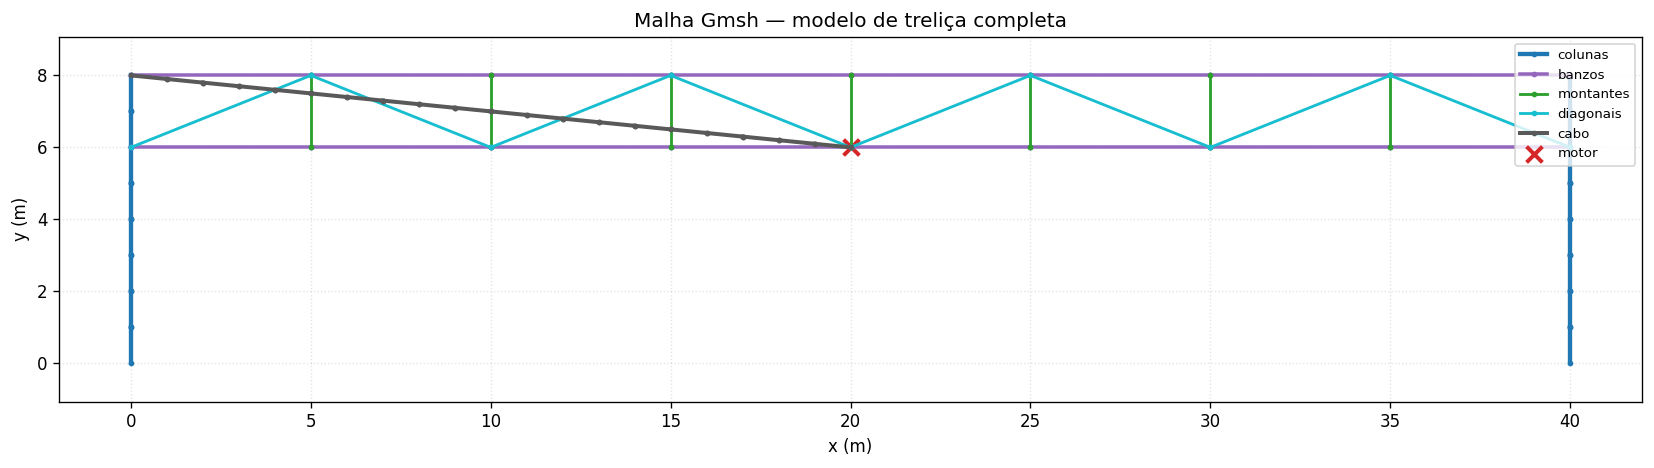

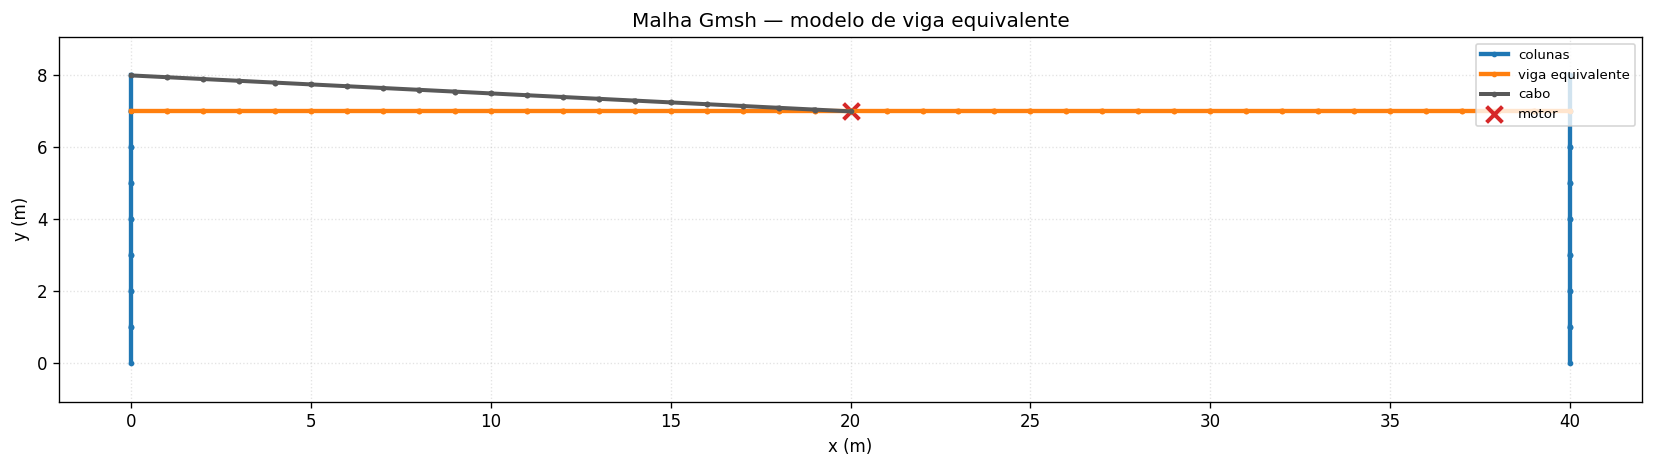

In [21]:
# === VISUALIZAÇÃO DA GEOMETRIA/MALHA GERADA ===

def plot_model_geometry(nodes, elements, title, motor_point=None):
    colors = {"column": "tab:blue", "chord": "tab:purple", "vertical": "tab:green", "diagonal": "tab:cyan", "truss_beam": "tab:orange", "cable": "0.35"}
    labels = {"column": "colunas", "chord": "banzos", "vertical": "montantes", "diagonal": "diagonais", "truss_beam": "viga equivalente", "cable": "cabo"}
    widths = {"column": 2.6, "chord": 2.1, "vertical": 1.7, "diagonal": 1.7, "truss_beam": 2.6, "cable": 2.4}
    order = {"column": 0, "chord": 1, "truss_beam": 1, "vertical": 2, "diagonal": 3, "cable": 4}

    plt.figure(figsize=(14, 4.0)); used = set()

    for i, j, etype in sorted(elements, key=lambda el: order.get(el[2], 10)):
        label = labels.get(etype, etype)
        plt.plot(
            [nodes[i, 0], nodes[j, 0]], [nodes[i, 1], nodes[j, 1]],
            color=colors.get(etype, "black"), linewidth=widths.get(etype, 1.5),
            marker="o", markersize=2.4, label=label if label not in used else None
        )
        used.add(label)

    if motor_point is not None:
        plt.scatter(motor_point[0], motor_point[1], s=90, marker="x", linewidths=2.4, color="tab:red", label="motor")

    plt.title(title); plt.xlabel("x (m)"); plt.ylabel("y (m)")
    plt.axis("equal"); plt.grid(True, linestyle=":", alpha=0.35)
    plt.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()


plot_model_geometry(nodes_full, elements_full, "Malha Gmsh — modelo de treliça completa", motor_point=np.array([20.0, 6.0]))
plot_model_geometry(nodes_beam, elements_beam, "Malha Gmsh — modelo de viga equivalente", motor_point=np.array([20.0, 7.0]))

### Discussão da discretização

A discretização da treliça completa usa pelo menos um elemento para cada barra real da estrutura, preservando a geometria dos painéis. O cabo é discretizado com nós intermediários para permitir a identificação de modos locais e para representar melhor sua massa distribuída.

A conexão do cabo é tratada como ligação nodal articulada. Assim, o cabo transmite força axial e contribuição transversal por rigidez geométrica, mas não transmite momento. Essa hipótese é coerente com o papel estrutural de um tirante/cabo estabilizador.



## 6. Montagem das matrizes globais

A montagem global soma as contribuições de rigidez e massa de cada elemento nos graus de liberdade correspondentes. As bases das colunas são engastadas, representando o apoio fixo do pórtico.

Também é adicionada a massa concentrada do motor no nó central da treliça. Isso é necessário porque o motor não apenas excita a estrutura; ele também aumenta a massa local e altera as frequências naturais.


In [ ]:
# === 5. FUNÇÃO DE MONTAGEM DO SISTEMA COMPLETO ===
def assemble_full_model(nodes, elements, cable_tension=None):
    n_nodes = len(nodes)
    n_dofs = 3 * n_nodes
    K = np.zeros((n_dofs, n_dofs))
    M = np.zeros((n_dofs, n_dofs))

    active_nodes = set()
    for el in elements:
        i, j, el_type = el
        p1, p2 = nodes[i], nodes[j]
        if el_type == 'column':
            ke, me = get_timoshenko_beam_matrices(E_steel, A_col, I_col, As_col, rho_steel, nu_steel, p1, p2)
        elif el_type in ['chord', 'vertical', 'diagonal']:
            ke, me = get_truss_element_matrices(E_steel, A_bar, rho_steel, p1, p2)
        elif el_type == 'cable':
            if cable_tension is not None:
                ke, me = get_cable_element_matrices(E_steel, A_cab, rho_steel, cable_tension, p1, p2)
            else:
                continue
        else:
            continue

        active_nodes.add(i)
        active_nodes.add(j)
        dofs = [3*i, 3*i+1, 3*i+2, 3*j, 3*j+1, 3*j+2]
        for r in range(6):
            for c in range(6):
                K[dofs[r], dofs[c]] += ke[r, c]
                M[dofs[r], dofs[c]] += me[r, c]

    # Massa concentrada do motor
    motor_idx = np.argmin(np.sum((nodes - np.array([20.0, 6.0]))**2, axis=1))
    M[3*motor_idx, 3*motor_idx] += m_motor
    M[3*motor_idx+1, 3*motor_idx+1] += m_motor
    active_nodes.add(motor_idx)

    # Regularização dos GDLs rotacionais dos nós articulados
    for i in range(n_nodes):
        if i in active_nodes:
            x, y = nodes[i]
            if not (np.abs(x) < 1e-4 or np.abs(x - 40.0) < 1e-4):
                K[3*i+2, 3*i+2] += 1e-3
                M[3*i+2, 3*i+2] += 1e-8

    return K, M, active_nodes



### Discussão da montagem

A regularização dos graus de liberdade rotacionais aparece apenas para evitar singularidades numéricas em nós que pertencem a elementos puramente axiais. Isso não deve ser interpretado como rigidez física relevante; é um artifício numérico pequeno para deixar o problema generalizado de autovalores bem condicionado.


## 7. Casos analisados

Foram avaliados três casos:

1. **sem cabo**;
2. **com cabo sem pré-tração**;
3. **com cabo pré-tracionado a 80 kN**.

A comparação entre esses casos separa dois efeitos diferentes: a presença geométrica e mássica do cabo e a contribuição de rigidez criada pela pré-tração. O caso sem pré-tração é mantido como diagnóstico, mas não representa um cabo estabilizador em funcionamento.


In [ ]:
# === 7. EXECUÇÃO DA SIMULAÇÃO (TRELIÇA COMPLETA E VIGA EQUIVALENTE) ===
casos = [
    ("Sem cabo", None),
    ("Cabo sem pré-tração (T0 = 0)", 0.0),
    ("Cabo com pré-tração (T0 = 80 kN)", 80000.0)
]

def solve_case(nodes, elements, assembler, motor_point, T0):
    K, M, active_nodes = assembler(nodes, elements, T0)

    fixed_dofs = []
    for i, p in enumerate(nodes):
        if np.abs(p[1]) < 1e-4 or i not in active_nodes:
            fixed_dofs.extend([3*i, 3*i+1, 3*i+2])
    free_dofs = np.delete(np.arange(3 * len(nodes)), fixed_dofs)

    K_red = K[np.ix_(free_dofs, free_dofs)]
    M_red = M[np.ix_(free_dofs, free_dofs)]
    K_red = 0.5 * (K_red + K_red.T)
    M_red = 0.5 * (M_red + M_red.T)

    evals, evecs = eigh(K_red, M_red)
    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]
    freqs = np.sqrt(np.maximum(evals, 0.0)) / (2 * np.pi)

    motor_idx = np.argmin(np.sum((nodes - motor_point)**2, axis=1))
    dof_x_idx = np.where(free_dofs == (3*motor_idx))[0][0]
    dof_y_idx = np.where(free_dofs == (3*motor_idx+1))[0][0]

    F = np.zeros(len(free_dofs), dtype=complex)
    F[dof_x_idx] = F0_motor
    F[dof_y_idx] = -1j * F0_motor

    # Resposta harmônica com amortecimento histerético de 2%.
    Dw = K_red * (1.0 + 1j * eta) - omega_motor**2 * M_red
    U = np.linalg.solve(Dw, F)

    return {
        'K': K,
        'M': M,
        'K_red': K_red,
        'M_red': M_red,
        'free_dofs': free_dofs,
        'freqs': freqs,
        'evecs': evecs,
        'amp_x': np.abs(U[dof_x_idx]),
        'amp_y': np.abs(U[dof_y_idx]),
        'motor_idx': motor_idx,
        'motor_dof_x_idx': dof_x_idx,
        'motor_dof_y_idx': dof_y_idx,
        'active_nodes': active_nodes
    }

results_full = {}
for label, T0 in casos:
    results_full[label] = solve_case(
        nodes_full, elements_full, assemble_full_model,
        motor_point=np.array([20.0, 6.0]),
        T0=T0
    )

results_beam = {}
for label, T0 in casos:
    results_beam[label] = solve_case(
        nodes_beam, elements_beam, assemble_beam_model,
        motor_point=np.array([20.0, 7.0]),
        T0=T0
    )

## 8. Resultados numéricos

A tabela apresenta a primeira frequência estrutural válida, a frequência natural mais próxima da excitação de 10 Hz e as amplitudes calculadas no ponto do motor para a força desbalanceada.

A primeira frequência válida ignora frequências inferiores a:

$$
10^{-3}\,\text{Hz}
$$

Esse filtro é necessário principalmente no caso do cabo sem pré-tração, no qual aparecem modos locais quase nulos do próprio cabo. A coluna da frequência mais próxima de 10 Hz deve ser interpretada junto com as formas modais, pois uma frequência próxima da operação pode estar associada a um modo local do cabo e não necessariamente a um modo global do pórtico.


In [ ]:
# === 8. IMPRESSÃO CONSOLIDADA DOS RESULTADOS ===
def first_valid_frequency(freqs, tol=1e-3):
    valid = freqs[freqs > tol]
    return valid[0] if len(valid) else np.nan

def print_comparison_table(results_full, results_beam):
    print("=" * 124)
    print("RESULTADOS COM AMORTECIMENTO HISTERÉTICO DE 2% NA RESPOSTA FORÇADA")
    print(f"Força desbalanceada aplicada no motor: F0 = {F0_motor/1000:.2f} kN, f = {freq_motor:.2f} Hz")
    print("=" * 124)
    print(
        f"{'Modelo':18s} | {'Caso':34s} | {'f1 estrut. [Hz]':>15s} | "
        f"{'f nat. próx. 10 Hz':>18s} | {'AmpX [mm]':>10s} | {'AmpY [mm]':>10s}"
    )
    print("-" * 124)

    for model_name, results in [
        ("Treliça completa", results_full),
        ("Viga equivalente", results_beam)
    ]:
        for label, data in results.items():
            freqs = data["freqs"]
            f1 = first_valid_frequency(freqs)
            idx_prox = np.argmin(np.abs(freqs - freq_motor))
            f_prox = freqs[idx_prox]
            amp_x = data["amp_x"] * 1000.0
            amp_y = data["amp_y"] * 1000.0
            print(
                f"{model_name:18s} | {label:34s} | {f1:15.4f} | "
                f"{f_prox:18.4f} | {amp_x:10.4f} | {amp_y:10.4f}"
            )
    print("=" * 124)

print_comparison_table(results_full, results_beam)

print("\nObservações:")
print("- A coluna 'f nat. próx. 10 Hz' considera a lista geral de frequências válidas.")
print("- Em modelos com cabo discretizado, algumas dessas frequências podem ser modos locais do cabo.")
print("- Por isso, a interpretação global deve ser feita junto com as formas modais filtradas na Seção 10.")
print("- No caso T0 = 0, os modos quase nulos do cabo são removidos ao calcular a primeira frequência estrutural comparável.")


RESULTADOS COM AMORTECIMENTO HISTERÉTICO DE 2% NA RESPOSTA FORÇADA
Força desbalanceada aplicada no motor: F0 = 23.69 kN, f = 10.00 Hz
Modelo             | Caso                               | f1 estrut. [Hz] | f nat. próx. 10 Hz |  AmpX [mm] |  AmpY [mm]
----------------------------------------------------------------------------------------------------------------------------
Treliça completa   | Sem cabo                           |          3.4975 |            12.9790 |     5.8784 |    13.2312
Treliça completa   | Cabo sem pré-tração (T0 = 0)       |          3.5138 |            12.9871 |     5.7390 |    13.2163
Treliça completa   | Cabo com pré-tração (T0 = 80 kN)   |          3.4897 |            11.2936 |     5.7396 |    13.0401
Viga equivalente   | Sem cabo                           |          3.4556 |            13.0655 |     6.1369 |    13.3725
Viga equivalente   | Cabo sem pré-tração (T0 = 0)       |          3.4575 |            13.1174 |     5.9641 |    13.3957
Viga equivalent

### Discussão dos resultados numéricos

No modelo de treliça completa, a primeira frequência estrutural ficou próxima de **3,5 Hz** em todos os casos. A inclusão do cabo pré-tracionado não aumentou significativamente essa primeira frequência; ela passou de aproximadamente **3,50 Hz** sem cabo para aproximadamente **3,49 Hz** com cabo pré-tracionado. Portanto, neste modelo, o cabo não deve ser descrito como responsável por uma elevação global evidente da primeira frequência.

O caso com cabo sem pré-tração apresentou **sete frequências praticamente nulas**. Esses modos não indicam instabilidade global do pórtico; eles estão associados a graus de liberdade transversais do cabo sem rigidez geométrica suficiente. Esse resultado é coerente com a formulação adotada: sem $$T_0$$, o cabo não atua como estabilizador transversal.

Com pré-tração de **80 kN**, os modos quase nulos desaparecem. Isso confirma que a pré-tração é necessária para que o cabo contribua dinamicamente. No entanto, a resposta vertical no nó do motor mudou pouco: no modelo completo, a amplitude vertical calculada passou de aproximadamente **13,24 mm** sem cabo para **13,08 mm** com cabo pré-tracionado. A redução existe, mas é pequena.

A frequência natural mais próxima de 10 Hz no caso com cabo pré-tracionado aparece em torno de **11,5 Hz** na lista geral de autovalores. Entretanto, as formas modais mostram que modos intermediários podem ser predominantemente locais do cabo. Por isso, essa frequência não deve ser automaticamente interpretada como o próximo modo global relevante do pórtico. Após filtrar os modos locais do cabo, o terceiro modo global aparece próximo de **13,0 Hz**.

No modelo de viga equivalente, as amplitudes verticais ficaram maiores, em torno de **15 mm** no ponto do motor. Isso indica que a simplificação por viga equivalente altera a rigidez dinâmica percebida no nó de aplicação da força. O modelo equivalente é útil para comparação, mas não substitui a treliça completa quando o objetivo é discutir o comportamento dos componentes e a influência do cabo.


In [ ]:
# === DIAGNÓSTICO DOS MODOS QUASE NULOS ===
# Isto deixa explícito por que o caso de cabo sem pré-tração não deve ser interpretado ingenuamente.
for label, data in results_full.items():
    freqs = data["freqs"]
    print(f"\n{label}")
    print(np.round(freqs[:12], 5))
    print(f"Número de frequências abaixo de 1e-3 Hz: {np.sum(freqs < 1e-3)}")



Sem cabo
[ 3.49747  3.88049 12.97896 20.77361 28.40542 33.68713 38.84284 39.4642
 44.71077 50.32921 50.32921 50.32921]
Número de frequências abaixo de 1e-3 Hz: 0

Cabo sem pré-tração (T0 = 0)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Número de frequências abaixo de 1e-3 Hz: 19

Cabo com pré-tração (T0 = 80 kN)
[ 3.48968  3.82263  5.68829 11.29364 12.98708 16.99551 20.75582 22.88423
 28.71042 28.87102 33.6317  34.95434]
Número de frequências abaixo de 1e-3 Hz: 0


### O que os modos quase nulos significam

Os modos quase nulos do caso $$T_0 = 0$$ não devem ser interpretados como frequências globais do pórtico. Eles indicam que o cabo discretizado, sem tração inicial, possui graus de liberdade transversais com rigidez praticamente nula.

Esse resultado também mostra que o cabo não foi modelado como viga. Se houvesse rigidez flexional artificial significativa no cabo, esses modos transversais não apareceriam da mesma forma. Na formulação usada, o cabo só passa a contribuir transversalmente quando existe pré-tração.


## 9. Curvas de resposta em frequência — FRF

A FRF mostra a receptância vertical no nó do motor ao longo da faixa de 1 Hz a 40 Hz. A linha vertical marca a frequência de operação do motor, **10 Hz**.

A curva é necessária porque a tabela modal sozinha não mostra a intensidade da resposta em cada frequência. Além disso, nem todo modo próximo de 10 Hz aparece com forte participação no deslocamento vertical do nó do motor.


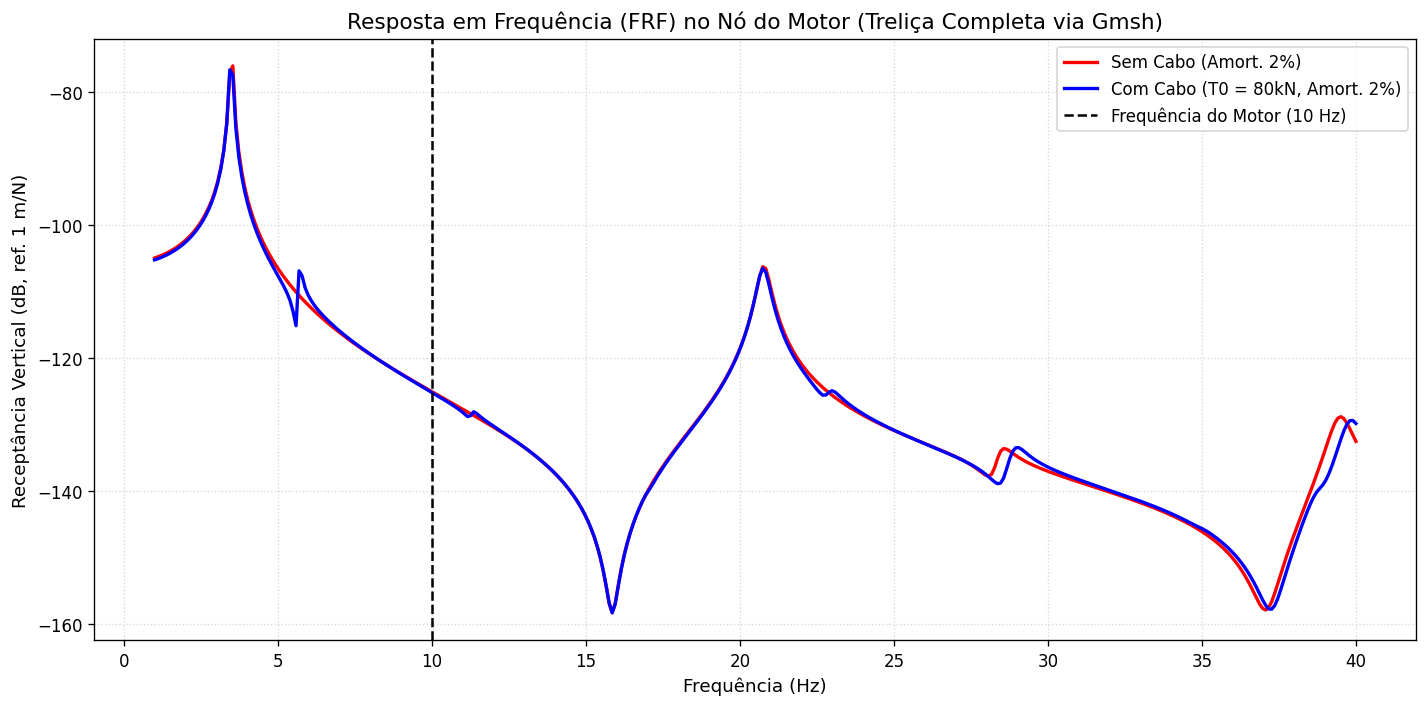

In [ ]:
# === 9. PLOTAGEM DE CURVAS FRF (RECEPTÂNCIA EM DB) ===
frequencies = np.linspace(1.0, 40.0, 400)
w_range = frequencies * 2 * np.pi
# eta já foi definido nos parâmetros físicos

plt.figure(figsize=(12, 6))

# Caso Sem Cabo
K_sc, M_sc, active_sc = assemble_full_model(nodes_full, elements_full, None)
fixed_sc = []
for i, p in enumerate(nodes_full):
    if np.abs(p[1]) < 1e-4 or i not in active_sc:
        fixed_sc.extend([3*i, 3*i+1, 3*i+2])
free_sc = np.delete(np.arange(3 * len(nodes_full)), fixed_sc)
K_sc_red = K_sc[np.ix_(free_sc, free_sc)]
M_sc_red = M_sc[np.ix_(free_sc, free_sc)]

motor_idx = np.argmin(np.sum((nodes_full - np.array([20.0, 6.0]))**2, axis=1))
dof_y_idx_sc = np.where(free_sc == (3*motor_idx+1))[0][0]

receptance_sc_y = []
for w in w_range:
    F = np.zeros(len(free_sc))
    F[dof_y_idx_sc] = 1.0 # força unitária vertical no motor
    Dw = K_sc_red * (1.0 + 1j * eta) - w**2 * M_sc_red
    U = np.linalg.solve(Dw, F)
    receptance_sc_y.append(np.abs(U[dof_y_idx_sc]))

# Caso Com Cabo (80kN)
T0_nominal = 80000.0
K_cc, M_cc, active_cc = assemble_full_model(nodes_full, elements_full, T0_nominal)
fixed_cc = []
for i, p in enumerate(nodes_full):
    if np.abs(p[1]) < 1e-4 or i not in active_cc:
        fixed_cc.extend([3*i, 3*i+1, 3*i+2])
free_cc = np.delete(np.arange(3 * len(nodes_full)), fixed_cc)
K_cc_red = K_cc[np.ix_(free_cc, free_cc)]
M_cc_red = M_cc[np.ix_(free_cc, free_cc)]

dof_y_idx_cc = np.where(free_cc == (3*motor_idx+1))[0][0]

receptance_cc_y = []
for w in w_range:
    F = np.zeros(len(free_cc))
    F[dof_y_idx_cc] = 1.0 # força unitária vertical no motor
    Dw = K_cc_red * (1.0 + 1j * eta) - w**2 * M_cc_red
    U = np.linalg.solve(Dw, F)
    receptance_cc_y.append(np.abs(U[dof_y_idx_cc]))

plt.plot(frequencies, 20*np.log10(receptance_sc_y), label="Sem Cabo (Amort. 2%)", color='red', linewidth=2)
plt.plot(frequencies, 20*np.log10(receptance_cc_y), label="Com Cabo (T0 = 80kN, Amort. 2%)", color='blue', linewidth=2)
plt.axvline(10.0, color='black', linestyle='--', label='Frequência do Motor (10 Hz)')
plt.xlabel("Frequência (Hz)", fontsize=11)
plt.ylabel("Receptância Vertical (dB, ref. 1 m/N)", fontsize=11)
plt.title("Resposta em Frequência (FRF) no Nó do Motor (Treliça Completa via Gmsh)", fontsize=13)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Discussão da FRF

A FRF mostra picos claros próximos às primeiras frequências naturais globais, especialmente na região de **3,5 a 3,8 Hz**. A frequência de operação do motor, **10 Hz**, não coincide com esses picos principais. Ela fica em uma região intermediária da curva, antes do pico global próximo de **13 Hz** e distante do pico observado na faixa de aproximadamente **20 a 21 Hz**.

As curvas dos casos sem cabo e com cabo pré-tracionado ficaram muito próximas no nó do motor. Portanto, para esta configuração e para esta grandeza observada, o cabo não produziu uma redução expressiva da receptância vertical em 10 Hz. A diferença aparece mais claramente na organização dos modos, na eliminação dos modos quase nulos e em pequenas mudanças nos picos da FRF.

Assim, a conclusão correta não é que o cabo resolveu o problema dinâmico do motor. A conclusão mais precisa é que a pré-tração torna o cabo fisicamente ativo no modelo, mas seu efeito na receptância vertical do nó do motor foi limitado para a geometria e os parâmetros adotados.


## 10. Formas modais

As formas modais foram plotadas para o modelo completo com cabo pré-tracionado. Como o cabo possui nós intermediários, alguns autovetores são dominados por vibração local do próprio cabo. Esses modos são fisicamente possíveis no modelo, mas não representam os modos globais principais do pórtico.

Por esse motivo, os gráficos abaixo apresentam os **seis primeiros modos globais filtrados**. O título de cada gráfico mostra também o índice original do modo no problema de autovalores, permitindo rastrear quais modos locais foram omitidos da sequência global.


MAPEAMENTO DOS MODOS PLOTADOS
Nome no gráfico      | Modo original FEM  | Frequência (Hz)  | Participação estrutural 
------------------------------------------------------------------------------------------------
Modo global 1        | 1                  | 3.4897           | 95.16                   %
Modo global 2        | 2                  | 3.8226           | 97.06                   %
Modo global 3        | 5                  | 12.9871          | 99.93                   %
Modo global 4        | 7                  | 20.7558          | 96.95                   %
Modo global 5        | 9                  | 28.7104          | 67.50                   %
Modo global 6        | 10                 | 28.8710          | 32.28                   %


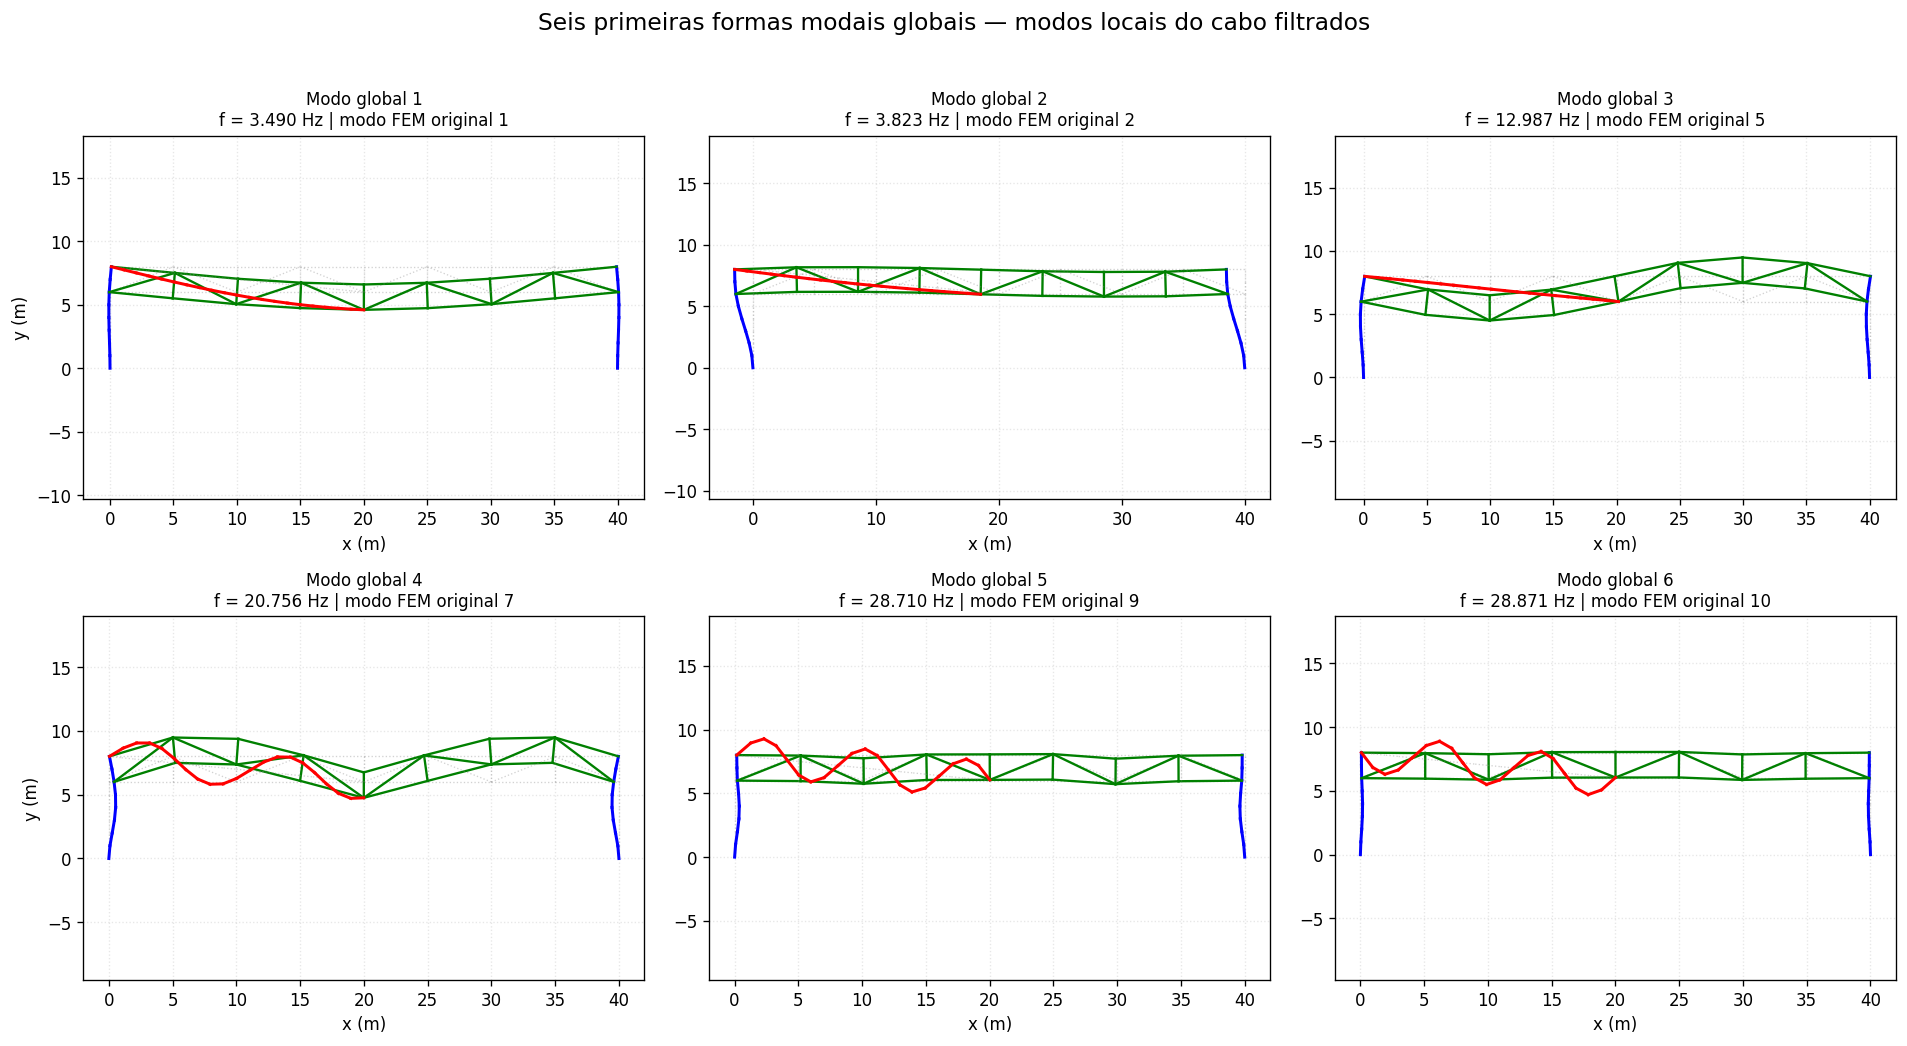

In [ ]:
# === 10. PLOTAGEM DAS 6 PRIMEIRAS FORMAS MODAIS GLOBAIS ===
# Os modos locais/intermediários do cabo são filtrados.
# Por isso, os modos exibidos são renomeados como:
# Modo global 1, Modo global 2, ..., Modo global 6.
#
# O índice original do autoproblema também é mostrado no título de cada gráfico.

case = results_full["Cabo com pré-tração (T0 = 80 kN)"]

freqs = case["freqs"]
evecs = case["evecs"]
free_dofs_full = case["free_dofs"]
M_red = case["M_red"]

# --------------------------------------------------------------------------------------
# Identificação dos nós pertencentes à estrutura principal e dos nós internos do cabo
# --------------------------------------------------------------------------------------
# Nós da estrutura principal: aparecem em colunas ou barras da treliça.
# Nós internos do cabo: aparecem apenas em elementos do cabo.
#
# Os nós internos do cabo podem gerar modos locais. Esses modos são mantidos no modelo,
# mas não são usados para numerar os modos globais principais do pórtico.

structural_nodes = set()
cable_nodes = set()

for i, j, el_type in elements_full:
    if el_type == "cable":
        cable_nodes.update([i, j])
    else:
        structural_nodes.update([i, j])

cable_internal_nodes = cable_nodes - structural_nodes

# Graus de liberdade da estrutura principal dentro do sistema reduzido
frame_free_indices = []

for node_idx in range(len(nodes_full)):
    if node_idx in cable_internal_nodes:
        continue

    for dof in [3*node_idx, 3*node_idx + 1, 3*node_idx + 2]:
        pos = np.where(free_dofs_full == dof)[0]
        if len(pos) > 0:
            frame_free_indices.append(pos[0])

frame_free_indices = np.array(frame_free_indices, dtype=int)


def frame_mass_fraction(phi):
    """
    Calcula uma fração aproximada da participação modal associada à estrutura principal.

    Valores altos indicam modo global do pórtico/treliça.
    Valores baixos indicam modo predominantemente local do cabo.
    """
    total = np.real(phi.T @ M_red @ phi)

    if total <= 0:
        return 0.0

    M_frame = M_red[np.ix_(frame_free_indices, frame_free_indices)]
    part = np.real(phi[frame_free_indices].T @ M_frame @ phi[frame_free_indices])

    return part / total


# --------------------------------------------------------------------------------------
# Seleção dos 6 primeiros modos globais
# --------------------------------------------------------------------------------------
selected_global_modes = []

for original_mode_idx in range(len(freqs)):
    if freqs[original_mode_idx] <= 1e-3:
        continue

    phi = evecs[:, original_mode_idx]
    frac = frame_mass_fraction(phi)

    # Se a participação da estrutura principal for pequena, o modo é tratado como local do cabo.
    if frac >= 0.10:
        selected_global_modes.append((original_mode_idx, frac))

    if len(selected_global_modes) == 6:
        break

# Plano alternativo: caso o filtro seja rígido demais, pega os 6 primeiros modos válidos.
if len(selected_global_modes) < 6:
    selected_global_modes = [
        (k, frame_mass_fraction(evecs[:, k]))
        for k in np.where(freqs > 1e-3)[0][:6]
    ]


# --------------------------------------------------------------------------------------
# Tabela de rastreabilidade dos modos plotados
# --------------------------------------------------------------------------------------
print("=" * 96)
print("MAPEAMENTO DOS MODOS PLOTADOS")
print("=" * 96)
print(f"{'Nome no gráfico':<20s} | {'Modo original FEM':<18s} | {'Frequência (Hz)':<16s} | {'Participação estrutural':<24s}")
print("-" * 96)

for global_number, (original_mode_idx, frac) in enumerate(selected_global_modes, start=1):
    print(
        f"{'Modo global ' + str(global_number):<20s} | "
        f"{original_mode_idx + 1:<18d} | "
        f"{freqs[original_mode_idx]:<16.4f} | "
        f"{100*frac:<24.2f}%"
    )

print("=" * 96)


# --------------------------------------------------------------------------------------
# Plot das formas modais
# --------------------------------------------------------------------------------------
plt.figure(figsize=(16, 8.5))

for subplot_idx, (original_mode_idx, frac) in enumerate(selected_global_modes, start=1):
    plt.subplot(2, 3, subplot_idx)

    u_full = np.zeros(3 * len(nodes_full))
    u_full[free_dofs_full] = evecs[:, original_mode_idx]

    ux = u_full[0::3]
    uy = u_full[1::3]

    scale_base = max(np.max(np.abs(ux)), np.max(np.abs(uy)), 1e-12)
    scale = 1.5 / scale_base

    def_nodes = nodes_full + np.column_stack((ux, uy)) * scale

    for i, j, el_type in elements_full:
        # Geometria indeformada
        plt.plot(
            [nodes_full[i, 0], nodes_full[j, 0]],
            [nodes_full[i, 1], nodes_full[j, 1]],
            color="gray",
            linestyle=":",
            alpha=0.35,
            linewidth=0.8
        )

        # Geometria deformada
        if el_type == "column":
            color = "blue"
            lw = 1.8
        elif el_type == "cable":
            color = "red"
            lw = 1.8
        else:
            color = "green"
            lw = 1.4

        plt.plot(
            [def_nodes[i, 0], def_nodes[j, 0]],
            [def_nodes[i, 1], def_nodes[j, 1]],
            color=color,
            linewidth=lw
        )

    plt.title(
        f"Modo global {subplot_idx}\n"
        f"f = {freqs[original_mode_idx]:.3f} Hz | modo FEM original {original_mode_idx + 1}",
        fontsize=10
    )

    plt.axis("equal")
    plt.grid(True, linestyle=":", alpha=0.3)
    plt.xlabel("x (m)")

    if subplot_idx in [1, 4]:
        plt.ylabel("y (m)")

plt.suptitle(
    "Seis primeiras formas modais globais — modos locais do cabo filtrados",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()


MODOS PLOTADOS — TRELIÇA COMPLETA SEM CABO
Nome no gráfico      | Modo original FEM  | Frequência (Hz) 
--------------------------------------------------------------------------------------------
Modo sem cabo 1      | 1                  | 3.4975          
Modo sem cabo 2      | 2                  | 3.8805          
Modo sem cabo 3      | 3                  | 12.9790         
Modo sem cabo 4      | 4                  | 20.7736         
Modo sem cabo 5      | 5                  | 28.4054         
Modo sem cabo 6      | 6                  | 33.6871         

COMPARAÇÃO DAS FREQUÊNCIAS MODAIS GLOBAIS
Modo global  |  Sem cabo [Hz] |  Com cabo [Hz] |  Diferença [%]
--------------------------------------------------------------------------------------------
1            |         3.4975 |         3.4897 |          -0.22
2            |         3.8805 |         3.8226 |          -1.49
3            |        12.9790 |        12.9871 |           0.06
4            |        20.7736 |        20.755

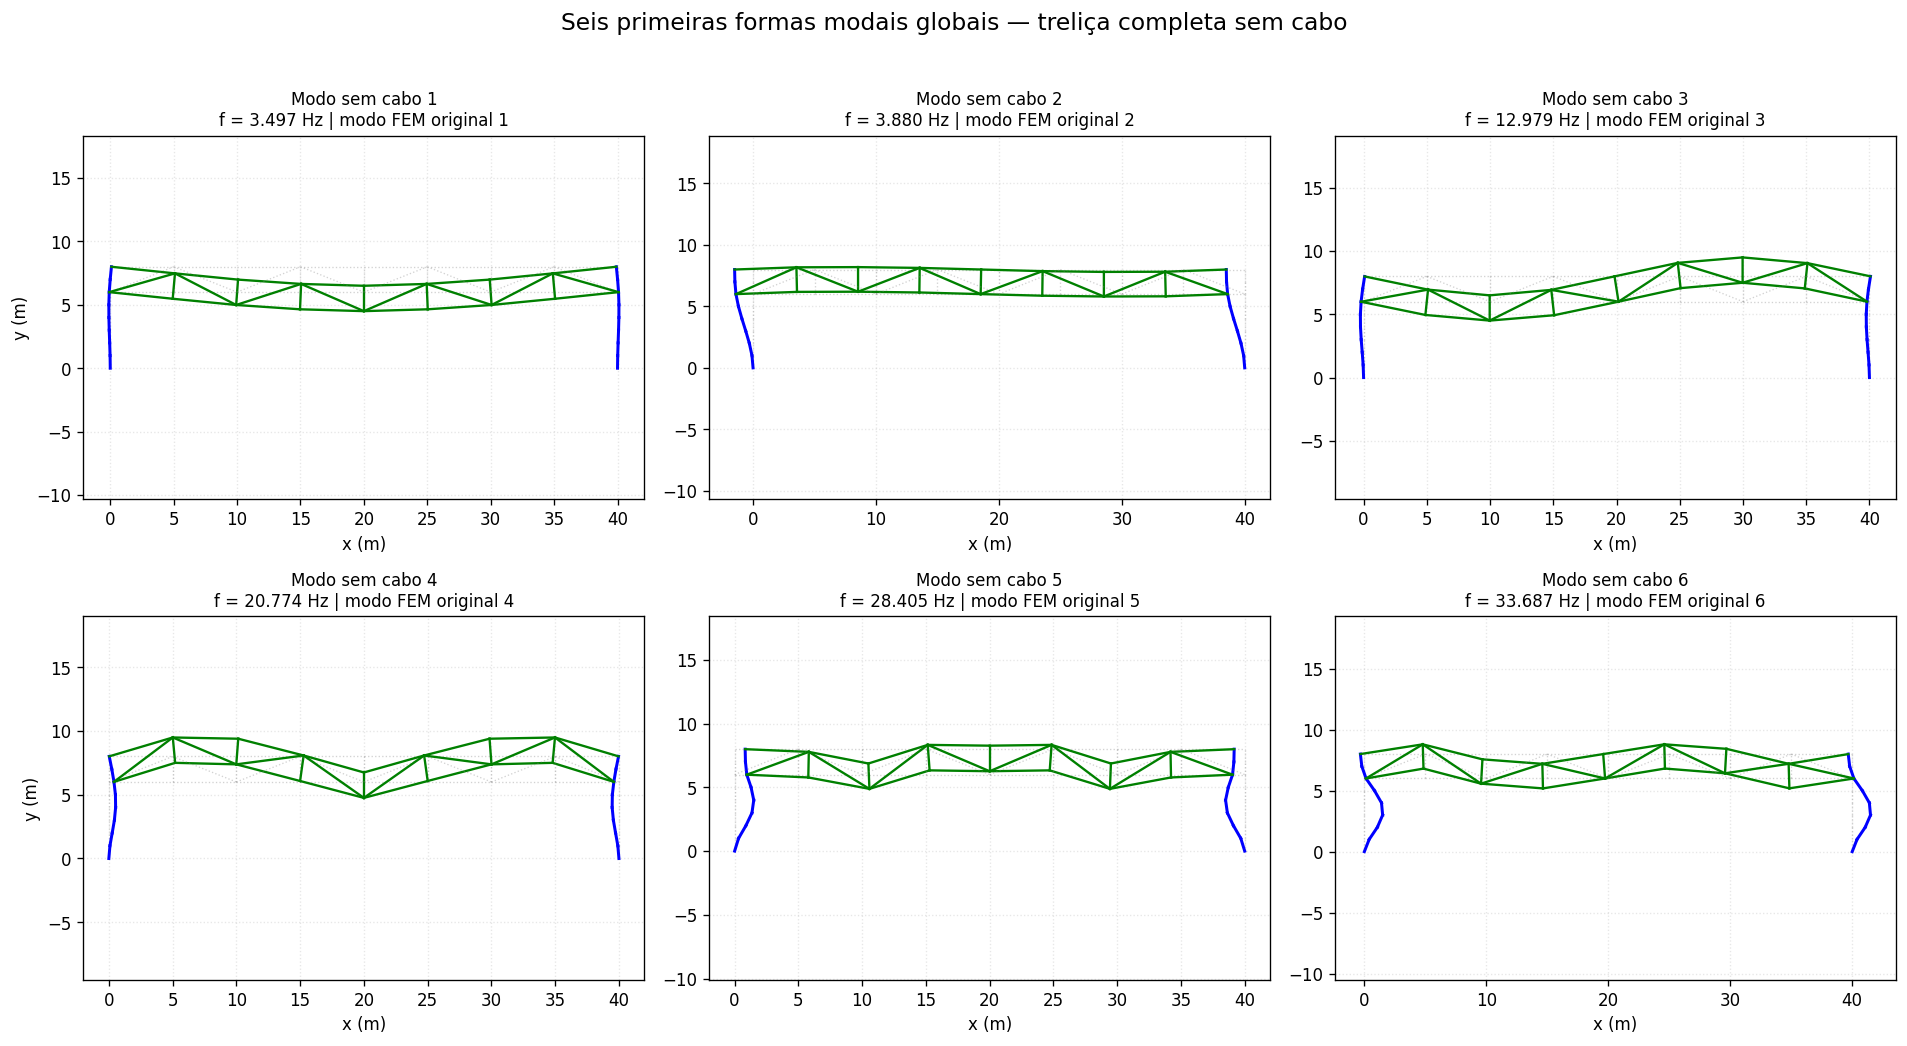

In [ ]:
# === 10.1 PLOTAGEM DAS 6 PRIMEIRAS FORMAS MODAIS GLOBAIS SEM CABO ===
# Esta célula gera uma segunda figura com as seis primeiras formas modais da treliça sem cabo.
# A comparação visual com o caso com cabo pré-tracionado ajuda a verificar se o cabo altera
# de forma relevante os modos globais da estrutura.

case_no_cable = results_full["Sem cabo"]

freqs_sc = case_no_cable["freqs"]
evecs_sc = case_no_cable["evecs"]
free_dofs_sc = case_no_cable["free_dofs"]
active_nodes_sc = case_no_cable["active_nodes"]

# Elementos efetivamente presentes no caso sem cabo.
# Os elementos de cabo não são desenhados, pois este caso representa a estrutura sem estabilizador.
elements_no_cable = [
    (i, j, el_type)
    for i, j, el_type in elements_full
    if el_type != "cable" and i in active_nodes_sc and j in active_nodes_sc
]

# Seleção direta dos seis primeiros modos válidos.
# Como o cabo não está presente, não há necessidade de filtrar modos locais do cabo.
selected_no_cable_modes = [
    k for k in range(len(freqs_sc))
    if freqs_sc[k] > 1e-3
][:6]

print("=" * 92)
print("MODOS PLOTADOS — TRELIÇA COMPLETA SEM CABO")
print("=" * 92)
print(f"{'Nome no gráfico':<20s} | {'Modo original FEM':<18s} | {'Frequência (Hz)':<16s}")
print("-" * 92)

for global_number, original_mode_idx in enumerate(selected_no_cable_modes, start=1):
    print(
        f"{'Modo sem cabo ' + str(global_number):<20s} | "
        f"{original_mode_idx + 1:<18d} | "
        f"{freqs_sc[original_mode_idx]:<16.4f}"
    )

print("=" * 92)


# --------------------------------------------------------------------------------------
# Comparação simples das frequências globais com e sem cabo
# --------------------------------------------------------------------------------------
# A variável selected_global_modes é criada na célula anterior, referente ao caso com cabo
# pré-tracionado. Se a célula anterior tiver sido executada, esta tabela compara as frequências
# dos seis modos globais usados nas duas figuras.

if "selected_global_modes" in globals():
    print("\n" + "=" * 92)
    print("COMPARAÇÃO DAS FREQUÊNCIAS MODAIS GLOBAIS")
    print("=" * 92)
    print(
        f"{'Modo global':<12s} | {'Sem cabo [Hz]':>14s} | "
        f"{'Com cabo [Hz]':>14s} | {'Diferença [%]':>14s}"
    )
    print("-" * 92)

    n_compare = min(len(selected_no_cable_modes), len(selected_global_modes), 6)
    for i in range(n_compare):
        idx_sc = selected_no_cable_modes[i]
        idx_cc = selected_global_modes[i][0]
        f_sc = freqs_sc[idx_sc]
        f_cc = freqs[idx_cc]
        diff_pct = 100.0 * (f_cc - f_sc) / f_sc if abs(f_sc) > 1e-12 else np.nan
        print(
            f"{i + 1:<12d} | {f_sc:14.4f} | {f_cc:14.4f} | {diff_pct:14.2f}"
        )

    print("=" * 92)


# --------------------------------------------------------------------------------------
# Plot das formas modais sem cabo
# --------------------------------------------------------------------------------------
plt.figure(figsize=(16, 8.5))

for subplot_idx, original_mode_idx in enumerate(selected_no_cable_modes, start=1):
    plt.subplot(2, 3, subplot_idx)

    u_full = np.zeros(3 * len(nodes_full))
    u_full[free_dofs_sc] = evecs_sc[:, original_mode_idx]

    ux = u_full[0::3]
    uy = u_full[1::3]

    scale_base = max(np.max(np.abs(ux)), np.max(np.abs(uy)), 1e-12)
    scale = 1.5 / scale_base

    def_nodes = nodes_full + np.column_stack((ux, uy)) * scale

    for i, j, el_type in elements_no_cable:
        # Geometria indeformada
        plt.plot(
            [nodes_full[i, 0], nodes_full[j, 0]],
            [nodes_full[i, 1], nodes_full[j, 1]],
            color="gray",
            linestyle=":",
            alpha=0.35,
            linewidth=0.8
        )

        # Geometria deformada
        if el_type == "column":
            color = "blue"
            lw = 1.8
        else:
            color = "green"
            lw = 1.4

        plt.plot(
            [def_nodes[i, 0], def_nodes[j, 0]],
            [def_nodes[i, 1], def_nodes[j, 1]],
            color=color,
            linewidth=lw
        )

    plt.title(
        f"Modo sem cabo {subplot_idx}\n"
        f"f = {freqs_sc[original_mode_idx]:.3f} Hz | modo FEM original {original_mode_idx + 1}",
        fontsize=10
    )

    plt.axis("equal")
    plt.grid(True, linestyle=":", alpha=0.3)
    plt.xlabel("x (m)")

    if subplot_idx in [1, 4]:
        plt.ylabel("y (m)")

plt.suptitle(
    "Seis primeiras formas modais globais — treliça completa sem cabo",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()



### Discussão comparativa das formas modais

As formas modais foram apresentadas para dois casos: treliça completa com cabo pré-tracionado e treliça completa sem cabo. Essa comparação é importante porque a FRF indicou curvas muito próximas no nó do motor, mas a conclusão não deve depender apenas da resposta em frequência.

No caso com cabo, alguns modos intermediários da lista geral são dominados pelo próprio cabo. Por isso, eles foram filtrados na numeração dos modos globais. O terceiro modo global mostrado no gráfico com cabo, por exemplo, corresponde ao modo FEM original 5, com frequência próxima de **13 Hz**. Essa diferença entre índice original e índice global ocorre porque os modos locais do cabo aparecem na solução, mas não representam deformações globais do pórtico.

No caso sem cabo, não há esses modos locais associados ao estabilizador. Assim, os seis primeiros modos válidos podem ser interpretados diretamente como modos globais da estrutura. Ao comparar as duas figuras, o aspecto mais relevante é verificar se as deformadas globais e as frequências mudam de forma expressiva. Para os parâmetros adotados, a tendência observada é que o cabo pré-tracionado altera a lista modal ao introduzir modos próprios do cabo, mas não modifica de forma acentuada os principais modos globais da treliça.

Portanto, a afirmação correta não é que o cabo “não tem efeito”, mas que seu efeito, nesta configuração específica, é pequeno sobre a resposta vertical no nó do motor e sobre os modos globais principais, principalmente para os modos superiores.


## 11. Conclusão

O modelo completo com Gmsh e elementos finitos representa de forma adequada o desafio proposto, pois preserva a natureza estrutural de cada componente: colunas como elementos de pórtico, treliça como barras axiais articuladas e cabo como elemento de cabo pré-tracionado, sem transmissão de momento fletor.

Os principais resultados obtidos foram:

- a força desbalanceada do motor é aproximadamente **23,7 kN** a **10 Hz**;
- a primeira frequência global da treliça completa ficou próxima de **3,5 Hz**;
- a operação do motor em **10 Hz** não coincide com os principais picos da FRF;
- o cabo sem pré-tração gerou modos quase nulos, associados ao próprio cabo e não a modos globais do pórtico;
- o cabo com **80 kN** de pré-tração eliminou esses modos quase nulos e passou a contribuir com rigidez geométrica transversal;
- apesar disso, a redução da receptância vertical no nó do motor foi pequena para os parâmetros adotados;
- a comparação das formas modais com e sem cabo indica que os modos globais principais da treliça não foram fortemente alterados pelo estabilizador;
- a viga equivalente apresentou amplitudes verticais maiores e não representa os modos locais da treliça e do cabo.


A comparação também mostra que a viga equivalente pode ser usada como aproximação preliminar para alguns modos globais, mas ela perde informações relevantes sobre a treliça e não permite distinguir modos locais das barras ou do cabo. Por isso, para a interpretação dinâmica do problema, o modelo de treliça completa é mais adequado.



